In [1]:
!nvidia-smi

Thu Feb  5 14:11:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.57                 Driver Version: 581.57         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050      WDDM  |   00000000:01:00.0  On |                  N/A |
| 34%   29C    P8              6W /   70W |     911MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Clean restart - run this FIRST after kernel restart
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from collections import Counter
import gc

# Clear GPU
torch.cuda.empty_cache()
gc.collect()

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ Using device: cuda
  GPU: NVIDIA GeForce RTX 3050


In [3]:
# Your paths
TRAIN_PATH = r"C:\Users\IbrahimNagyElsaid\datasetTeeth\Teeth_Dataset\Training"
VAL_PATH = r"C:\Users\IbrahimNagyElsaid\datasetTeeth\Teeth_Dataset\Validation"
TEST_PATH = r"C:\Users\IbrahimNagyElsaid\datasetTeeth\Teeth_Dataset\Testing"

# Safe settings for RTX 3050
IMG_SIZE = 224          # Single number, not tuple!
BATCH_SIZE = 8          # Small to avoid memory errors
NUM_WORKERS = 0         # No multiprocessing = more stable
NUM_CLASSES = 7
EPOCHS = 35
LEARNING_RATE = 0.001

print("✓ Settings configured")


✓ Settings configured


In [4]:
# Training transforms (with augmentation)
# Safe preprocessing for clinical images
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # Keep original proportions
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],  # Simple normalization
                         std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

print("✓ Transforms created")

✓ Transforms created


In [5]:
# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Print info
print(f"✓ Classes: {train_dataset.classes}")
print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Validation samples: {len(val_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")

# Final check
assert len(train_dataset.classes) == NUM_CLASSES, "Class count mismatch!"
print(f"\n✅ Data loaded successfully!")

✓ Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
✓ Training samples: 3087
✓ Validation samples: 1028
✓ Test samples: 1043

✅ Data loaded successfully!


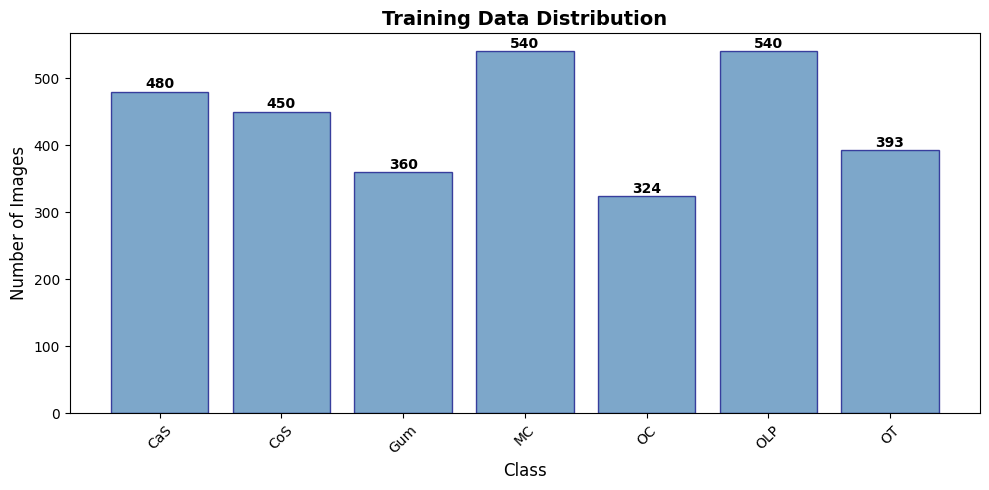

✓ Saved: class_distribution.png


In [6]:
# Count samples per class
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

# Prepare data for plotting
classes = train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts, color='steelblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Training Data Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add counts on bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_x() + bar.get_width()/2, count + 5, 
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✓ Saved: class_distribution.png")

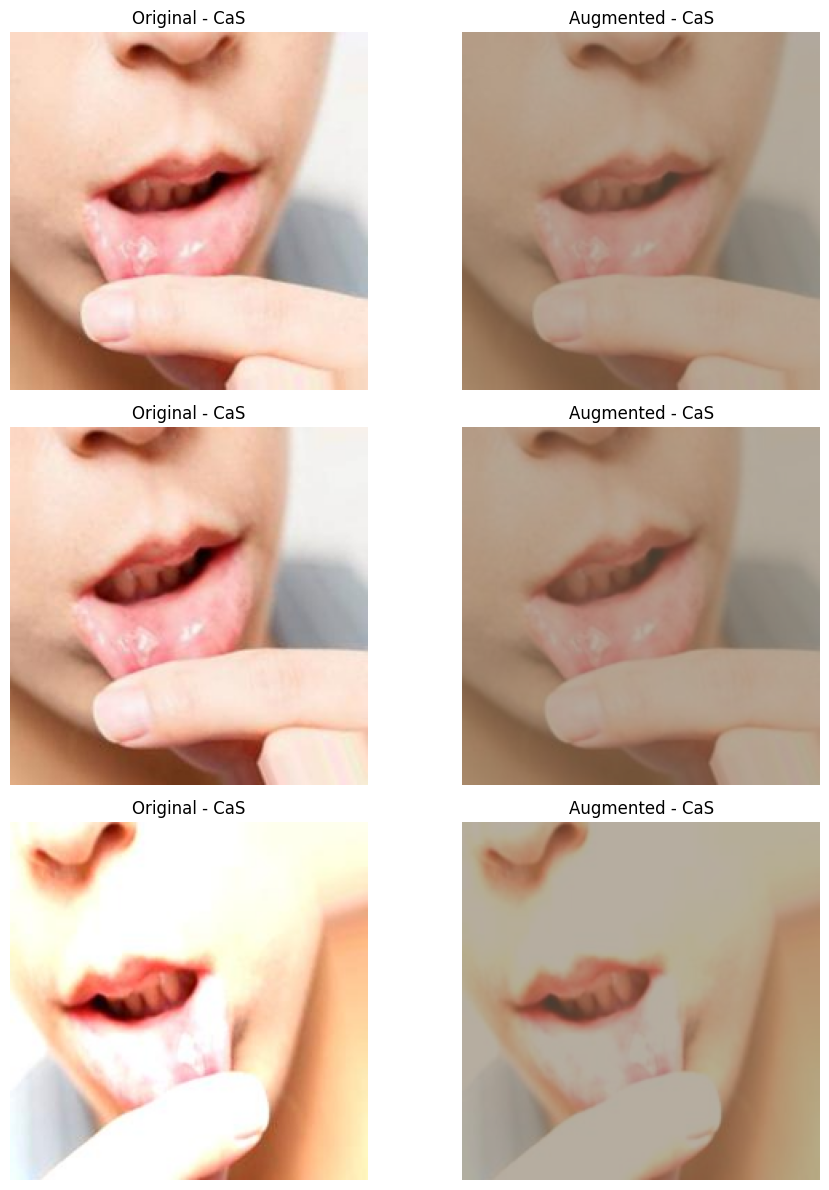

✓ Saved: augmentation_examples.png


In [7]:
# Show before/after augmentation
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i in range(3):
    # Get original image
    img_path, label = train_dataset.samples[i]
    original = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    
    # Get augmented (need to access raw then transform)
    augmented_tensor = train_transform(Image.open(img_path))
    
    # Denormalize augmented
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    augmented = augmented_tensor * std + mean
    augmented = torch.clamp(augmented, 0, 1).permute(1, 2, 0).numpy()
    
    # Plot
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f'Original - {train_dataset.classes[label]}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(augmented)
    axes[i, 1].set_title(f'Augmented - {train_dataset.classes[label]}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150)
plt.show()
print("✓ Saved: augmentation_examples.png")

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class ClinicalCNN_900K(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # ↓↓↓ reduced width here (128 → 192, NOT 256)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 192, 3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.gap = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.classifier(x)

# Create model
model = ClinicalCNN_900K(num_classes=NUM_CLASSES).to(device)
print(f"✓ Model created: {sum(p.numel() for p in model.parameters()):,} parameters")

✓ Model created: 708,327 parameters


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("✓ Optimizer and loss ready")

✓ Optimizer and loss ready


In [10]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': total_loss/(pbar.n+1), 'acc': 100.*correct/total})
    
    return total_loss/len(loader), 100.*correct/total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
    
    return total_loss/len(loader), 100.*correct/total

print("✓ Training functions ready")

✓ Training functions ready


In [11]:
# Run this to see if classes are balanced
from collections import Counter

train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)

print("Class Distribution:")
for i, cls in enumerate(train_dataset.classes):
    count = class_counts[i]
    percentage = 100 * count / len(train_dataset)
    print(f"{cls:10s}: {count:4d} samples ({percentage:.1f}%)")

Class Distribution:
CaS       :  480 samples (15.5%)
CoS       :  450 samples (14.6%)
Gum       :  360 samples (11.7%)
MC        :  540 samples (17.5%)
OC        :  324 samples (10.5%)
OLP       :  540 samples (17.5%)
OT        :  393 samples (12.7%)


In [12]:
# ============================================
# COMPLETE RETRAIN WITH ALL FIXES
# ============================================

print("Checking class distribution...")
train_labels = [label for _, label in train_dataset.samples]
class_counts = Counter(train_labels)
total = len(train_labels)

print("\nClass Distribution:")
for i, cls in enumerate(train_dataset.classes):
    count = class_counts[i]
    percentage = 100 * count / total
    print(f"{cls:10s}: {count:4d} ({percentage:.1f}%)")

# Calculate class weights
class_weights = torch.tensor([total / (NUM_CLASSES * class_counts[i]) 
                               for i in range(NUM_CLASSES)], dtype=torch.float32).to(device)
print(f"\nClass weights: {class_weights.cpu().numpy()}")

# Weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Better model
model = ClinicalCNN_900K(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Better optimizer settings
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# Training
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

print("\n" + "="*60)
print("RETRAINING WITH FIXES")
print("="*60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/20")
    print("-"*60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_improved.pth')
        print(f"✓ Saved! Best Val Acc: {val_acc:.2f}%")

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE - Best Val Acc: {best_val_acc:.2f}%")
print(f"{'='*60}")

Checking class distribution...

Class Distribution:
CaS       :  480 (15.5%)
CoS       :  450 (14.6%)
Gum       :  360 (11.7%)
MC        :  540 (17.5%)
OC        :  324 (10.5%)
OLP       :  540 (17.5%)
OT        :  393 (12.7%)

Class weights: [0.91875    0.98       1.225      0.81666666 1.3611112  0.81666666
 1.1221374 ]
Model parameters: 708,327

RETRAINING WITH FIXES

Epoch 1/20
------------------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 129/129 [00:17<00:00,  7.56it/s]



Train: Loss=1.8006, Acc=27.31%
Val:   Loss=1.6475, Acc=32.39%
✓ Saved! Best Val Acc: 32.39%

Epoch 2/20
------------------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 129/129 [00:08<00:00, 15.75it/s]



Train: Loss=1.6303, Acc=34.40%
Val:   Loss=1.6983, Acc=34.63%
✓ Saved! Best Val Acc: 34.63%

Epoch 3/20
------------------------------------------------------------


...


Train: Loss=0.8592, Acc=67.31%
Val:   Loss=0.7680, Acc=71.79%

Epoch 34/20
------------------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 129/129 [00:07<00:00, 16.44it/s]



Train: Loss=0.8739, Acc=67.51%
Val:   Loss=0.8282, Acc=67.22%

Epoch 35/20
------------------------------------------------------------


Validating: 100%|████████████████████████████████████████████████████████████████████| 129/129 [00:08<00:00, 15.69it/s]


Train: Loss=0.8657, Acc=65.69%
Val:   Loss=0.7698, Acc=72.08%

TRAINING COMPLETE - Best Val Acc: 73.54%


In [14]:
torch.save(model.state_dict(), "best_model_improved900.pth")


In [13]:
print("Train classes:", train_dataset.classes)
print("Test classes: ", test_dataset.classes)


Train classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Test classes:  ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [14]:
model = ClinicalCNN_900K(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load("best_model_improved900.pth", map_location=device))
model.eval()


ClinicalCNN_900K(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d

In [15]:
import torch
import torch.nn.functional as F

def test_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    avg_loss = test_loss / total
    acc = 100.0 * correct / total

    return avg_loss, acc, all_targets, all_preds


In [16]:
from torchvision import transforms

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # resize to CNN input size
    transforms.ToTensor(),              # convert to tensor
    transforms.Normalize(               # normalize with ImageNet-like stats or your dataset mean/std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [17]:
test_loss, test_acc, y_true, y_pred = test_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.7213
Test Accuracy: 76.61%


In [18]:
print("Train classes:", train_dataset.classes)
print("Val classes:  ", val_dataset.classes)
print("Test classes: ", test_dataset.classes)


Train classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Val classes:   ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Test classes:  ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [19]:
from collections import Counter
print("Predicted distribution:", Counter(y_pred))
print("True distribution:", Counter(y_true))


Predicted distribution: Counter({3: 184, 5: 172, 6: 163, 1: 146, 0: 138, 4: 136, 2: 104})
True distribution: Counter({3: 180, 5: 180, 0: 160, 1: 149, 6: 146, 2: 120, 4: 108})


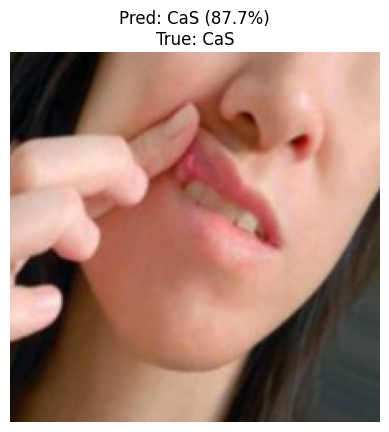

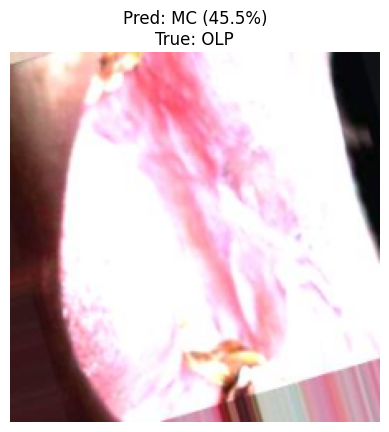

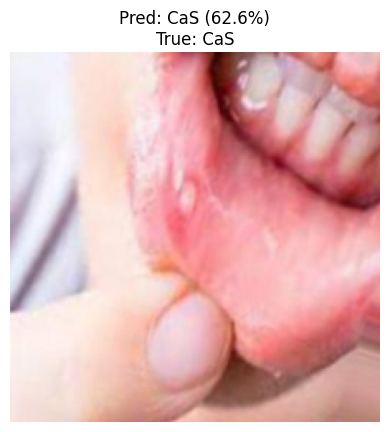

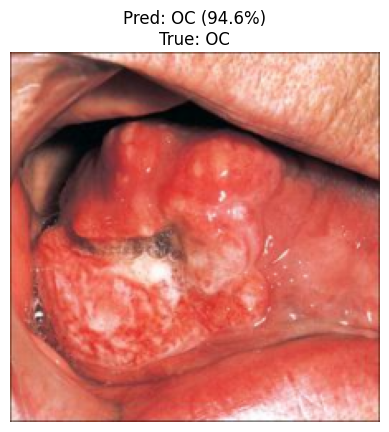

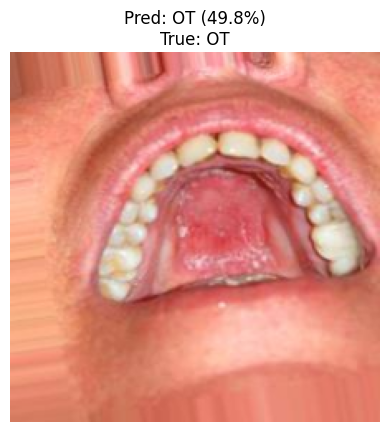

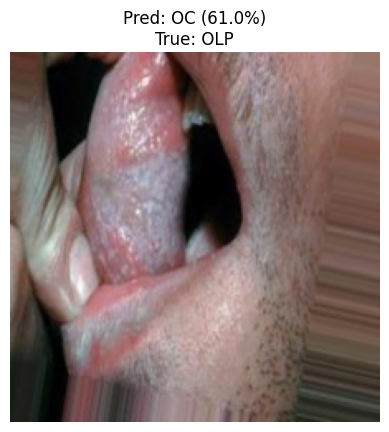

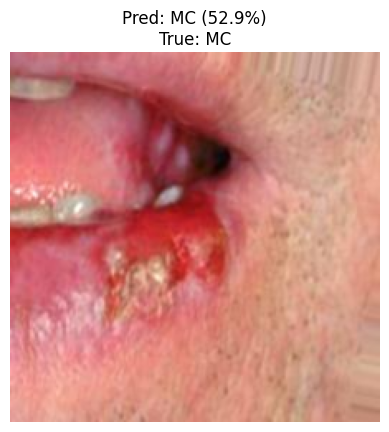

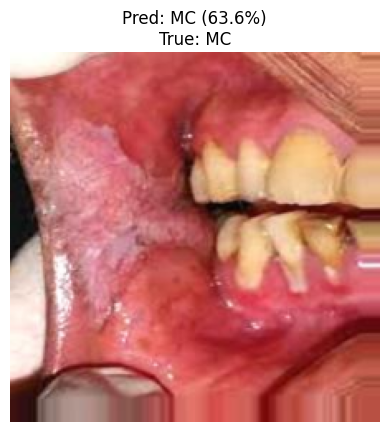

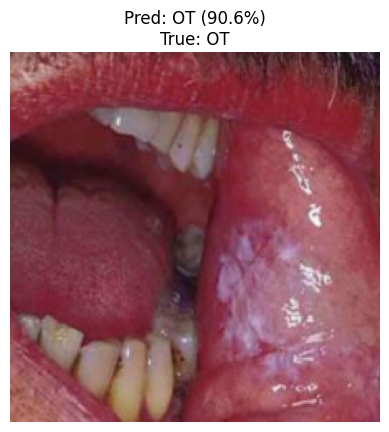

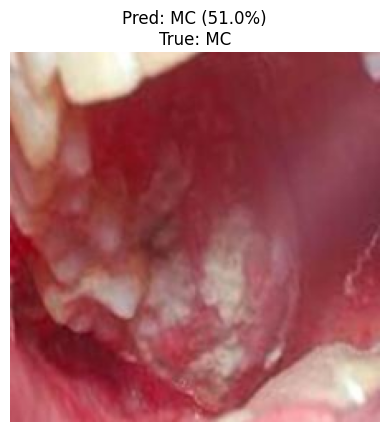

In [20]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# --- 1. Load the test dataset ---
IMG_SIZE = 224
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

test_dataset = datasets.ImageFolder(r'C:\Users\IbrahimNagyElsaid\datasetTeeth\Teeth_Dataset\Testing', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Map class index to name
idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

# --- 2. Load the trained model ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ClinicalCNN_900K().to(device)
model.load_state_dict(torch.load('best_model_improved900.pth', map_location=device))
model.eval()

# --- 3. Visualization function ---
def imshow(img_tensor, title=None):
    img = img_tensor.squeeze().permute(1,2,0).cpu().numpy()
    img = (img * 0.5) + 0.5  # denormalize
    plt.imshow(np.clip(img, 0, 1))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)



# --- 4. Iterate over a few test images ---
num_images_to_show = 10
count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)

        title = f"Pred: {idx_to_class[pred.item()]} ({conf.item()*100:.1f}%)\nTrue: {idx_to_class[labels.item()]}"
        imshow(images[0], title)

        count += 1
        if count >= num_images_to_show:
            break


In [21]:
import torch
import numpy as np

# 1. Initialize empty lists to store results
all_labels = []
all_preds = []

# 2. Set model to evaluation mode (deactivates dropout/batchnorm)
model.eval()

# 3. Disable gradient calculation for faster inference and less memory use
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model (CPU or GPU)
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Get the index of the highest logit (the prediction)
        _, preds = torch.max(outputs, 1)
        
        # Move back to CPU and convert to numpy to store
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# 4. Convert lists to numpy arrays so the classification report can read them
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print("Evaluation complete. Variable 'all_labels' is now defined!")

Evaluation complete. Variable 'all_labels' is now defined!


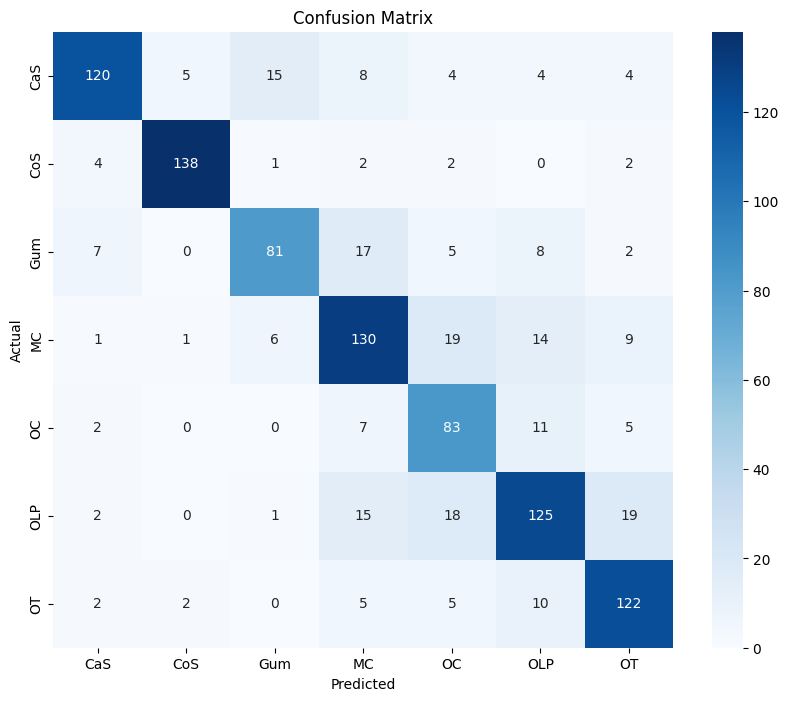

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_dataset.classes, 
            yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [1]:
!git init


Initialized empty Git repository in C:/Users/IbrahimNagyElsaid/.git/


In [4]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 6C63-2738

 Directory of C:\Users\IbrahimNagyElsaid

02/05/2026  11:33 AM    <DIR>          .
01/25/2026  01:58 PM    <DIR>          ..
02/04/2026  09:37 AM    <DIR>          .conda
01/25/2026  01:54 PM    <DIR>          .dotnet
02/05/2026  11:33 AM    <DIR>          .ipynb_checkpoints
01/26/2026  09:44 AM    <DIR>          .ipython
02/01/2026  03:45 PM    <DIR>          .jupyter
02/04/2026  10:00 AM    <DIR>          .keras
02/04/2026  10:39 AM    <DIR>          .matplotlib
02/04/2026  01:28 PM           203,239 augmentation_example.png
02/05/2026  10:13 AM         1,139,117 augmentation_examples.png
02/05/2026  10:12 AM         2,500,567 best_model version2.pt
02/05/2026  10:32 AM         4,605,749 best_model.pt
02/04/2026  02:56 PM           524,789 best_model.pth
02/05/2026  08:34 AM         2,856,968 best_model_improved.pth
02/05/2026  08:48 AM         2,857,209 best_model_improved900.pth
02/05/2026  10:13 AM            40,

In [5]:
!git add "Teeth_classification_Imporved_Net.ipynb"

In [6]:
!git commit -m "Implemented ClinicalCNN_900K with 224x224 input and test visualization for a clinic System"

[master (root-commit) 0a84e14] Implemented ClinicalCNN_900K with 224x224 input and test visualization for a clinic System
 Committer: Ibrahim Nagy Elsaid <ibrahim.nagy@saudi-tech.com.sa>
Your name and email address were configured automatically based
on your username and hostname. Please check that they are accurate.
You can suppress this message by setting them explicitly. Run the
following command and follow the instructions in your editor to edit
your configuration file:

    git config --global --edit

After doing this, you may fix the identity used for this commit with:

    git commit --amend --reset-author

 1 file changed, 1842 insertions(+)
 create mode 100644 Teeth_classification_Imporved_Net.ipynb


In [7]:
!git remote add origin https://github.com/hima-84/Teeth_Classification.git

In [8]:
!git branch -M main

In [9]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


To https://github.com/hima-84/Teeth_Classification.git
 * [new branch]      main -> main


In [20]:
"""
Script to generate per-class classification metrics for teeth classification model.
Run this after evaluating your model to get detailed performance metrics.
"""

import numpy as np
from sklearn.metrics import classification_report, precision_recall_fscore_support

def generate_classification_metrics(y_true, y_pred, class_names):
    """
    Generate detailed per-class metrics.
    
    Args:
        y_true: Ground truth labels (numpy array or list)
        y_pred: Predicted labels (numpy array or list)
        class_names: List of class names in order
    
    Returns:
        Dictionary with detailed metrics
    """
    
    # Convert to numpy arrays if needed
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Get precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    # Calculate overall metrics
    precision_avg, recall_avg, f1_avg, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    # Print detailed report
    print("\n" + "="*70)
    print("DETAILED PER-CLASS CLASSIFICATION REPORT")
    print("="*70)
    
    # Header
    print(f"\n{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*70)
    
    # Per-class metrics
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} "
              f"{f1[i]:<12.4f} {support[i]:<10}")
    
    print("-"*70)
    print(f"{'WEIGHTED AVG':<10} {precision_avg:<12.4f} {recall_avg:<12.4f} "
          f"{f1_avg:<12.4f} {sum(support):<10}")
    print("="*70)
    
    # Generate README markdown table
    print("\n\nREADME MARKDOWN TABLE:")
    print("-"*70)
    print("| Class | Precision | Recall | F1-Score | Support |")
    print("|-------|-----------|--------|----------|---------|")
    for i, class_name in enumerate(class_names):
        print(f"| {class_name:<5} | {precision[i]:.4f}    | {recall[i]:.4f} | {f1[i]:.4f}   | {support[i]:<7} |")
    print(f"| **Weighted Avg** | **{precision_avg:.4f}** | **{recall_avg:.4f}** | **{f1_avg:.4f}** | **{sum(support)}** |")
    print("-"*70)
    
    # Also print sklearn's built-in classification report
    print("\n\nSKLEARN CLASSIFICATION REPORT:")
    print("-"*70)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support,
        'precision_avg': precision_avg,
        'recall_avg': recall_avg,
        'f1_avg': f1_avg
    }


# Example usage:
if __name__ == "__main__":
    print("""
    HOW TO USE THIS SCRIPT:
    
    After running your model evaluation in the notebook, you should have:
    - y_true (or all_labels): actual labels
    - y_pred (or all_preds): predicted labels
    
    Then run:
    
    from generate_metrics import generate_classification_metrics
    
    class_names = ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
    metrics = generate_classification_metrics(y_true, y_pred, class_names)
    
    This will print:
    1. Detailed metrics table
    2. Markdown table for README
    3. Full sklearn classification report
    """)
    
    # Example with dummy data (replace with your actual data)
    print("\n" + "="*70)
    print("EXAMPLE OUTPUT (with dummy data):")
    print("="*70)
    
    # Create some dummy predictions for demonstration
    np.random.seed(42)
    n_samples = 100
    n_classes = 7
    
    y_true_example = np.random.randint(0, n_classes, n_samples)
    y_pred_example = y_true_example.copy()
    # Add some errors
    error_indices = np.random.choice(n_samples, 20, replace=False)
    y_pred_example[error_indices] = np.random.randint(0, n_classes, 20)
    
    class_names = ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
    
    metrics = generate_classification_metrics(y_true_example, y_pred_example, class_names)


    HOW TO USE THIS SCRIPT:
    
    After running your model evaluation in the notebook, you should have:
    - y_true (or all_labels): actual labels
    - y_pred (or all_preds): predicted labels
    
    Then run:
    
    from generate_metrics import generate_classification_metrics
    
    class_names = ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
    metrics = generate_classification_metrics(y_true, y_pred, class_names)
    
    This will print:
    1. Detailed metrics table
    2. Markdown table for README
    3. Full sklearn classification report
    

EXAMPLE OUTPUT (with dummy data):

DETAILED PER-CLASS CLASSIFICATION REPORT

Class      Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
CaS        0.6154       1.0000       0.7619       8         
CoS        0.9444       1.0000       0.9714       17        
Gum        0.7000       0.6364       0.6667       11        
MC         0.8889       0.7619       0.

In [24]:
!git config --global user.email "ibrahim.nagy@saudi-tech.com.sa"
!git config --global user.name "Ibrahim Nagy Elsaid"

In [23]:
!git rm "Teeth_classification_Imporved_Net.ipynb"


fatal: not a git repository (or any of the parent directories): .git


In [24]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 6C63-2738

 Directory of C:\Users\IbrahimNagyElsaid

02/05/2026  02:54 PM    <DIR>          .
01/25/2026  01:58 PM    <DIR>          ..
02/04/2026  09:37 AM    <DIR>          .conda
01/25/2026  01:54 PM    <DIR>          .dotnet
02/05/2026  01:39 PM                75 .gitconfig
02/05/2026  01:37 PM               189 .gitignore
02/05/2026  01:59 PM    <DIR>          .ipynb_checkpoints
01/26/2026  09:44 AM    <DIR>          .ipython
02/01/2026  03:45 PM    <DIR>          .jupyter
02/04/2026  10:00 AM    <DIR>          .keras
02/04/2026  10:39 AM    <DIR>          .matplotlib
02/04/2026  01:28 PM           203,239 augmentation_example.png
02/05/2026  02:11 PM         1,139,117 augmentation_examples.png
02/05/2026  10:12 AM         2,500,567 best_model version2.pt
02/05/2026  10:32 AM         4,605,749 best_model.pt
02/04/2026  02:56 PM           524,789 best_model.pth
02/05/2026  02:29 PM         2,856,968 best_model_improved.pth
0

In [28]:
%cd "C:\Users\IbrahimNagyElsaid\Downloads\Teeth Classification"


C:\Users\IbrahimNagyElsaid\Downloads\Teeth Classification


C:\Users\IbrahimNagyElsaid\AppData\Local\ESRI\conda\envs\teeth_gpu\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [30]:
!git rm Teeth_classification_Imporved_Net.ipynb



fatal: pathspec 'Teeth_classification_Imporved_Net.ipynb' did not match any files


In [31]:
!git status 

On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore
	new file:   requirements.txt

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Teeth_classification_Imporved_Net.ipynb



In [34]:
!git branch  